# PROPHECG-Age Single Inference Notebook

이 노트북에서는 다음 항목을 수행합니다:

1. **Model weight** (`models/model.pth`) 로드  ← #1  
2. **Sample input** (`data/sample_input.csv`) 로드 및 시각화 ← #2, #4  
3. **Pre-processing** 함수 불러오기 및 적용 ← #3  
4. **Inference**: 전처리된 파형으로부터 연령 예측 ← #4  


Sample input 로드 & 시각화 (Code)
### 셀 2: Sample ECG 데이터 로드 및 원파형 시각화

In [2]:
import os
os.chdir('/home/wellysis/PROPHECG_Age_Single_home')
print("이제 작업 디렉터리:", os.getcwd())

이제 작업 디렉터리: /home/wellysis/PROPHECG_Age_Single_home


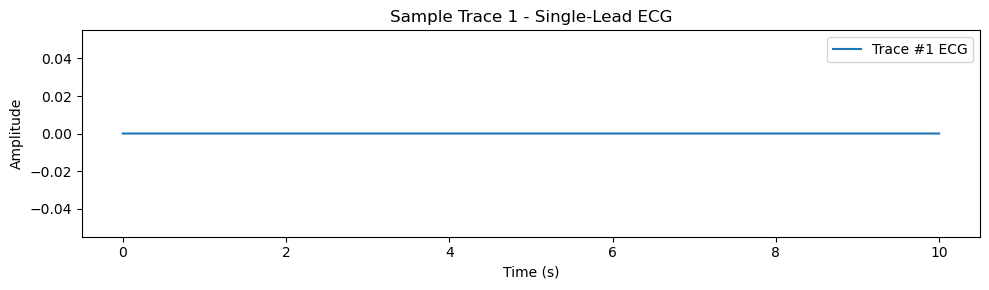

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) CSV 로드
csv_path = 'data/sample_trace_4.csv'
df = pd.read_csv(csv_path)

# 2) 시간 및 ECG 신호 추출
time = df['time'].values
ecg  = df['ecg'].values

# 3) ECG 파형 플롯
plt.figure(figsize=(10, 3))
plt.plot(time, ecg, label='Trace #1 ECG')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Sample Trace 1 - Single-Lead ECG')
plt.legend()
plt.tight_layout()
plt.show()


전처리 적용 및 시각화 (Code)

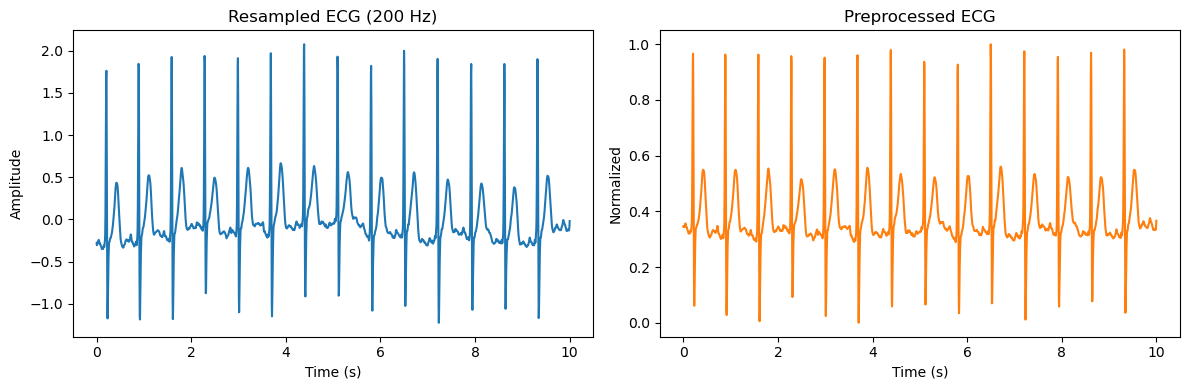

In [55]:
# ── Cell 4: Resample → Preprocess → Visualize (#3, #4) ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample
from src.preprocess import preprocess_ecg


# 1) 샘플 CSV 로드
csv_path = 'data/sample_trace_5.csv'
df = pd.read_csv(csv_path)
time_raw = df['time'].values       # e.g. length 2560
ecg_raw  = df['ecg'].values        # same length

# 2) 리샘플링: 256 Hz → 200 Hz
fs_src = 256
fs_tgt = 200
n_tgt  = int(len(ecg_raw) * fs_tgt / fs_src)  # → 2000 points
ecg_rs = resample(ecg_raw, n_tgt)

# 3) 새로운 시간 벡터 (0 – 10 s, 200 Hz)
time_rs = np.linspace(0, 10, n_tgt)

# 4) 전처리 적용
ecg_proc = preprocess_ecg(ecg_rs, fs=fs_tgt)

# 5) 원본 vs 전처리 결과 시각화
plt.figure(figsize=(12,4))

# (a) 리샘플링 후 원파형
plt.subplot(1,2,1)
plt.plot(time_rs, ecg_rs, color='C0')
plt.title('Resampled ECG (200 Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()

# (b) 전처리된 파형
plt.subplot(1,2,2)
plt.plot(time_rs, ecg_proc, color='C1')
plt.title('Preprocessed ECG')
plt.xlabel('Time (s)')
plt.ylabel('Normalized')
plt.tight_layout()

plt.show()


모델 로드 및 Inference (Code)

In [45]:
# Cell 5: 모델 로드 및 Inference (#1, #4)
import os, sys
import torch

# 1) src 폴더를 파이썬 패스에 추가 (노트북 루트 기준)
project_root = os.getcwd()
sys.path.insert(0, os.path.join(project_root, 'src'))

# 2) 모델 클래스 import
from resnet import ResNet1d_mse

# 3) 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 4) 하이퍼파라미터
N_LEADS = 1
SEQ_LEN = ecg_proc.shape[0]        # 보통 2000
BLOCKS  = [(32,2000),(64,400),(128,80),(256,16),(512,4)]
KERNEL  = 7
DROPOUT = 0.4
SCALE   = 5                        # 학습 시 age*5 스케일링

# 5) 모델 초기화
model = ResNet1d_mse(
    input_dim=(N_LEADS, SEQ_LEN),
    blocks_dim=BLOCKS,
    n_classes=1,
    kernel_size=KERNEL,
    dropout_rate=DROPOUT
)

# 6) 가중치 로드
weight_path = os.path.join(project_root, 'models', 'model.pth')
checkpoint = torch.load(weight_path, map_location=device)
state_dict = checkpoint.get('model', checkpoint)
model.load_state_dict(state_dict)

# 7) 모델 평가 모드 설정
model.to(device)
model.eval()

# 8) 전처리된 ECG → 텐서 변환
#    ecg_proc: numpy array, shape (2000,)
x = torch.from_numpy(ecg_proc.astype('float32')) \
         .unsqueeze(0).unsqueeze(0).to(device)  # (1,1,SEQ_LEN)

# 9) Inference
with torch.no_grad():
    out = model(x).item()

# 10) 스케일 복원 및 출력
predicted_age = out * SCALE
print(f"▶ Predicted ECG Age: {predicted_age:.2f} years")


Using device: cuda
▶ Predicted ECG Age: 53.79 years


---

## 결과 요약

- **Raw ECG**: `data/sample_input.csv`  
- **Preprocessed ECG**: DC 제거 → 밴드패스 → 정규화  
- **Predicted Age**: *<셀에서 출력된 값>* years

위 과정을 통해 누구나 모델 가중치를 활용해 ECG-Age 예측을 재현할 수 있습니다.
